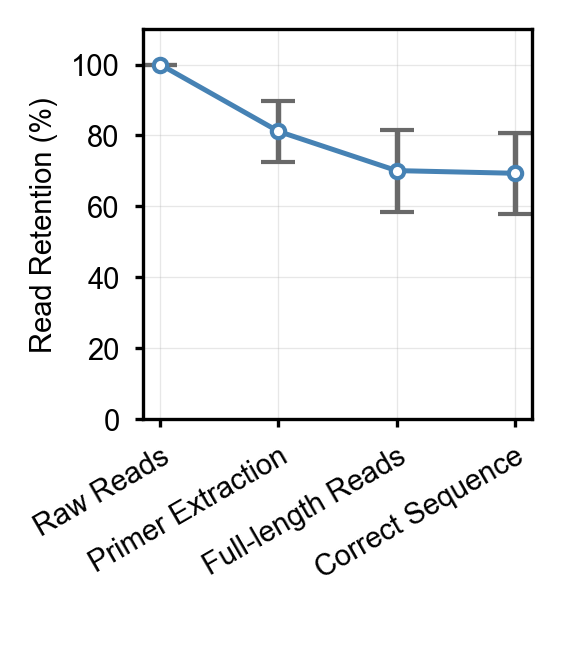

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================== 数据读取 ==================
df = pd.read_excel("data_get_rate/data_info_get_rate.xlsx", sheet_name="Sheet2")
steps = df.iloc[:, 0]
raw_reads = df.iloc[0, 1:]
retention = df.iloc[:, 1:] / raw_reads.values
mean_retention = retention.mean(axis=1) * 100
std_retention  = retention.std(axis=1)  * 100

# ================== 字体与图形参数 ==================
cm = 1 / 2.54
plt.rcParams["font.family"]   = "Arial"
plt.rcParams["font.size"]     = 7
plt.rcParams["pdf.fonttype"]  = 42
plt.rcParams["svg.fonttype"]  = "path"   # 转曲线避免重叠

# ================== Axes 精确 3.3 cm × 3.3 cm ==================
AX_W, AX_H = 3.3 * cm, 3.3 * cm
LEFT, RIGHT, TOP, BOTTOM = 0.40, 0.1, 0.10, 0.6   # inch，底部留足空间防截断

FIG_W = LEFT + AX_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax  = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])

# ================== 绘制折线 + 误差棒 ==================
ax.errorbar(
    steps, mean_retention, yerr=std_retention,
    fmt='o-', color='steelblue',
    ecolor='dimgray', elinewidth=1.3, capsize=4.0, capthick=1.0,
    markersize=3.2, linewidth=1.2,
    markerfacecolor='white', markeredgecolor='steelblue'
)

# ================== 坐标轴与样式 ==================
ax.set_ylim(0, 110)
ax.set_xlabel(" ", fontsize=7, labelpad=2)
ax.set_ylabel("Read Retention (%)", fontsize=7, labelpad=3)
ax.set_xticks(range(len(steps)))
ax.set_xticklabels(steps, rotation=30, ha='right', rotation_mode='anchor')
ax.tick_params(axis='both', labelsize=7, length=2)
ax.grid(alpha=0.3, linewidth=0.3)

# ================== 保存 ==================
# PDF：可编辑文本（出版友好）
fig.savefig("data_get_rate/data_get_rate.pdf", format="pdf",
            bbox_inches=None, pad_inches=0)

# SVG：文字转曲线，绝不重叠
fig.savefig("data_get_rate/data_get_rate.svg", format="svg",
            bbox_inches=None, pad_inches=0)

plt.show()


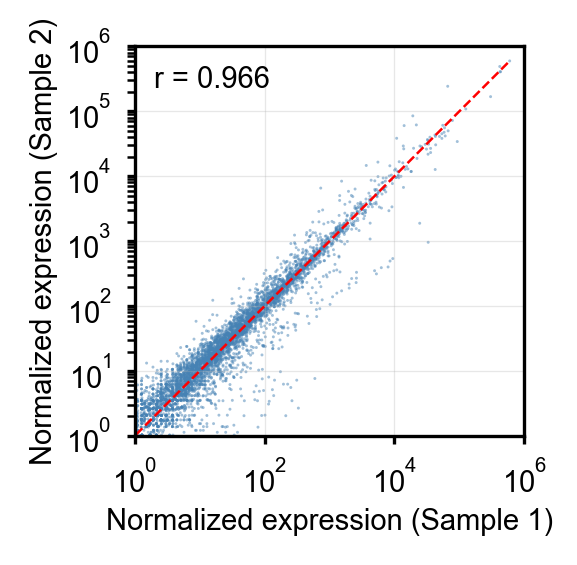

In [13]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== 参数 ==========
file1 = "rep/bulk_rep.xlsx"
file2 = "rep/bulk_rep.xlsx"
sheet = 0

# ========== 标准化函数 ==========
def normalize_total_counts(df, scale=1_000_000):
    """每行是一个样本/脑区；把每行总 counts 归一到 scale（默认 1e6）"""
    df = df.apply(pd.to_numeric, errors="coerce")

    row_sum = df.sum(axis=1)  # 每个样本总counts
    row_sum = row_sum.replace(0, np.nan)  # 避免除以0

    df_norm = df.div(row_sum, axis=0) * scale
    return df_norm


# ========== 读取并标准化 ==========
df1 = normalize_total_counts(pd.read_excel(file1, sheet_name='r2', index_col=0))
df2 = normalize_total_counts(pd.read_excel(file2, sheet_name='r3', index_col=0))

# 对齐基因
common_genes = df1.columns.intersection(df2.columns)
df1 = df1[common_genes]
df2 = df2[common_genes]

# 展平为向量
vals1 = df1.stack()
vals2 = df2.stack()
df_compare = pd.DataFrame({"Sample1": vals1, "Sample2": vals2}).dropna()

# ========== 计算总体相关性 ==========
r = df_compare["Sample1"].corr(df_compare["Sample2"], method="pearson")

# ========== 绘制散点图（Axes = 3.3 cm × 3.3 cm） ==========
cm = 1 / 2.54
AX_W, AX_H = 3.3 * cm, 3.3 * cm

# 图像边距（inch）
LEFT, RIGHT, BOTTOM, TOP = 0.4, 0.2, 0.4, 0.2
FIG_W = LEFT + AX_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 7
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "path"

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])

# 绘制点
ax.scatter(df_compare["Sample1"], df_compare["Sample2"],
           s=0.5, alpha=0.5, color="steelblue", edgecolor="none")

# y=x 参考线
lims = [
    min(df_compare.min().min(), df_compare.min().min()),
    max(df_compare.max().max(), df_compare.max().max())
]
ax.plot(lims, lims, "r--", lw=0.6)

# 坐标样式
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1, 1_000_000)
ax.set_ylim(1, 1_000_000)
ax.set_xlabel("Normalized expression (Sample 1)", fontsize=7, labelpad=2)
ax.set_ylabel("Normalized expression (Sample 2)", fontsize=7, labelpad=2)
ax.tick_params(labelsize=7, length=2)
ax.grid(alpha=0.3, lw=0.3)

# 标注相关系数
ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
        ha="left", va="top", fontsize=7)

# 保存
fig.savefig("rep/rep.svg", format="svg", bbox_inches=None, pad_inches=0)
fig.savefig("rep/rep.pdf", format="pdf", bbox_inches=None, pad_inches=0)
plt.show()


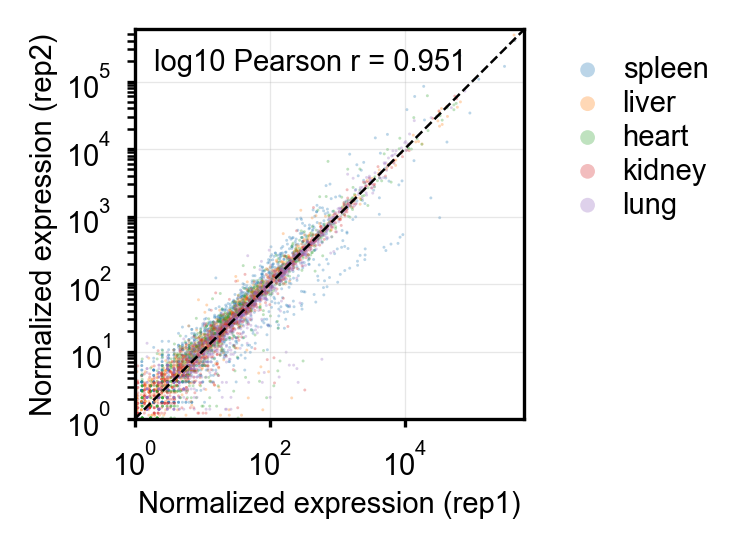

In [12]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ========== 参数 ==========
file1 = "rep/bulk_rep.xlsx"   # 或者你的 r1 文件
file2 = "rep/bulk_rep.xlsx"   # 或者你的 r2 文件
sheet1 = "r2"
sheet2 = "r3"

# 五种组织的顺序（可选；不填就按表里行名顺序）
tissue_order = None  # 例如 ["heart","kidney","liver","lung","spleen"]

out_svg = "rep/rep_by_tissue.svg"
out_pdf = "rep/rep_by_tissue.pdf"

# ========== 标准化函数 ==========
def normalize_total_counts(df, scale=1_000_000):
    """每行是一个组织；把每行总 counts 归一到 scale（默认 1e6）"""
    df = df.apply(pd.to_numeric, errors="coerce")
    row_sum = df.sum(axis=1).replace(0, np.nan)
    df_norm = df.div(row_sum, axis=0) * scale
    return df_norm

# ========== 读取并标准化 ==========
df1 = normalize_total_counts(pd.read_excel(file1, sheet_name=sheet1, index_col=0))
df2 = normalize_total_counts(pd.read_excel(file2, sheet_name=sheet2, index_col=0))

# 对齐：组织（行） + 基因（列）都取交集
common_tissues = df1.index.intersection(df2.index)
common_genes = df1.columns.intersection(df2.columns)
df1 = df1.loc[common_tissues, common_genes]
df2 = df2.loc[common_tissues, common_genes]

# 组织顺序
if tissue_order is None:
    tissues = list(df1.index)
else:
    tissues = [t for t in tissue_order if t in df1.index]

# ========== 全局字体/导出设置 ==========
cm = 1 / 2.54
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",   # 让 svg 保留文字（不转路径）
})

# ========== 计算总体相关性（所有组织所有基因汇总） ==========
all_vals1 = df1.to_numpy().ravel()
all_vals2 = df2.to_numpy().ravel()
m = np.isfinite(all_vals1) & np.isfinite(all_vals2) & (all_vals1 > 0) & (all_vals2 > 0)
r_all = np.corrcoef(np.log10(all_vals1[m]), np.log10(all_vals2[m]))[0, 1]  # 用 log 空间更稳

# ========== 绘图：Axes = 3.3 cm × 3.3 cm ==========
AX_W, AX_H = 3.3 * cm, 3.3 * cm
LEFT, RIGHT, BOTTOM, TOP = 0.4, 0.9, 0.4, 0.2  # 右边留 legend 空间（可调）
FIG_W = LEFT + AX_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])

# 颜色：5 种组织（使用 tab10 前几色，稳定且易区分）
cmap = plt.get_cmap("tab10")
colors = {t: cmap(i) for i, t in enumerate(tissues)}

# ========== 分组织散点 ==========
for t in tissues:
    x = df1.loc[t].values.astype(float)
    y = df2.loc[t].values.astype(float)
    ok = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    ax.scatter(x[ok], y[ok],
               s=0.5, alpha=0.3,
               c=[colors[t]], edgecolors="none",
               label=str(t))

# y=x 参考线（log 坐标）
# 取全体的范围（避免写死 1~1e6）
xmin = np.nanmin(df1.to_numpy()[df1.to_numpy() > 0])
xmax = np.nanmax(df1.to_numpy())
ymin = np.nanmin(df2.to_numpy()[df2.to_numpy() > 0])
ymax = np.nanmax(df2.to_numpy())
lo = max(1, np.nanmin([xmin, ymin]))
hi = np.nanmax([xmax, ymax])
ax.plot([lo, hi], [lo, hi], "k--", lw=0.6)

# 坐标样式
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Normalized expression (rep1)", labelpad=2)
ax.set_ylabel("Normalized expression (rep2)", labelpad=2)
ax.tick_params(length=2)
ax.grid(alpha=0.3, lw=0.3)

# 标注相关系数（log 空间）
ax.text(0.05, 0.95, f"log10 Pearson r = {r_all:.3f}",
        transform=ax.transAxes, ha="left", va="top")

# legend 放右侧，不改变 ax 物理尺寸
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0),
          frameon=False, handletextpad=0.2, labelspacing=0.2,
          markerscale=5)

# 保存（不使用 bbox_inches='tight'，以免改变物理尺寸）
fig.savefig(out_svg, format="svg", bbox_inches=None, pad_inches=0)  
fig.savefig(out_pdf, format="pdf", bbox_inches=None, pad_inches=0)
plt.show()
plt.close(fig)


In [11]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

file1 = "rep/bulk_rep.xlsx"
file2 = "rep/bulk_rep.xlsx"
sheet1 = "r2"
sheet2 = "r3"

outdir = Path("rep/by_tissue")
outdir.mkdir(parents=True, exist_ok=True)

def normalize_total_counts(df, scale=1_000_000):
    df = df.apply(pd.to_numeric, errors="coerce")
    row_sum = df.sum(axis=1).replace(0, np.nan)
    return df.div(row_sum, axis=0) * scale

# 读取并标准化
df1 = normalize_total_counts(pd.read_excel(file1, sheet_name=sheet1, index_col=0))
df2 = normalize_total_counts(pd.read_excel(file2, sheet_name=sheet2, index_col=0))

# 对齐：组织与基因
common_tissues = df1.index.intersection(df2.index)
common_genes = df1.columns.intersection(df2.columns)
df1 = df1.loc[common_tissues, common_genes]
df2 = df2.loc[common_tissues, common_genes]

# 组织顺序（可选：写成你的 5 个组织名）
tissues = list(df1.index)

# 全局字体
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

cm = 1/2.54
AX_W, AX_H = 3.3*cm, 3.3*cm
LEFT, RIGHT, BOTTOM, TOP = 0.4, 0.2, 0.4, 0.2  # inch
FIG_W = LEFT + AX_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

# 全局范围（保证 5 张图坐标一致，便于横向比较）
Xall = df1.to_numpy()
Yall = df2.to_numpy()
m = np.isfinite(Xall) & np.isfinite(Yall) & (Xall > 0) & (Yall > 0)
lo = max(1, np.nanmin(np.minimum(Xall[m], Yall[m])))
hi = np.nanmax(np.maximum(Xall[m], Yall[m]))

for t in tissues:
    x = df1.loc[t].values.astype(float)
    y = df2.loc[t].values.astype(float)
    ok = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

    # 相关系数：建议在 log10 空间算，更稳（动态范围大）
    r = np.corrcoef(np.log10(x[ok]), np.log10(y[ok]))[0, 1] if ok.sum() > 2 else np.nan

    fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
    ax = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])

    ax.scatter(x[ok], y[ok], s=1.0, alpha=0.5, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.6)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_xlabel("Normalized expression (rep1)", labelpad=2)
    ax.set_ylabel("Normalized expression (rep2)", labelpad=2)
    ax.tick_params(length=2)
    ax.grid(alpha=0.3, lw=0.3)

    ax.text(0.05, 0.95, f"{t}\nlog10 r = {r:.3f}",
            transform=ax.transAxes, ha="left", va="top")

    fig.savefig(outdir / f"rep_{t}.pdf", bbox_inches=None, pad_inches=0)
    fig.savefig(outdir / f"rep_{t}.svg", bbox_inches=None, pad_inches=0)
    plt.close(fig)

print("Saved to:", outdir)


Saved to: rep\by_tissue


C:\Users\Administrator\AppData\Local\Temp\ipykernel_45684\1782065589.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_45684\1782065589.py:101: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 20000000)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_45684\1782065589.py:102: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 20000000)


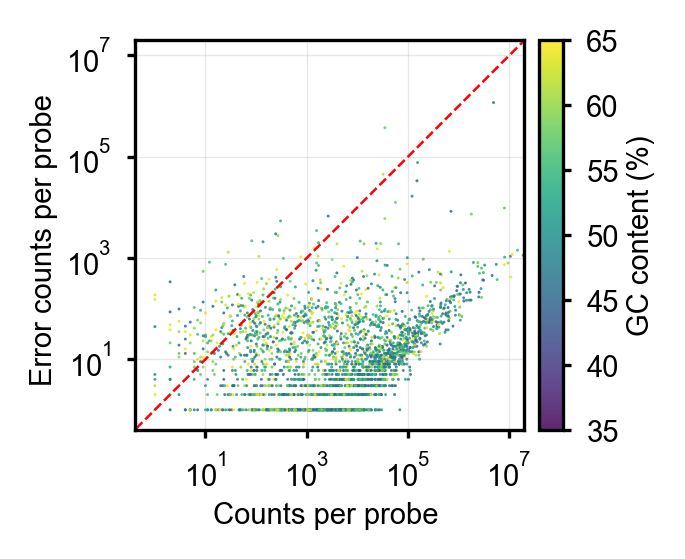

In [13]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# =========================
# 读取数据
# =========================
xlsx_path = "error_rate/error_umi_info.xlsx"

# Sheet1: 三列（基因序号、探针序号、GC比例）
info = pd.read_excel(xlsx_path, sheet_name=0, header=0).iloc[:, :3].copy()
info.columns = ["gene_id", "probe_id", "gc_ratio"]

# Sheet2: 行=探针、列=样本，总 counts
counts = pd.read_excel(xlsx_path, sheet_name=2, header=0)
# Sheet3: 行=探针、列=样本，错误 counts
errors = pd.read_excel(xlsx_path, sheet_name=1, header=0)-counts

def maybe_drop_first_id_col(df_like, expected_rows):
    """若首列是ID，则去掉；要求行数与Sheet1一致"""
    if df_like.shape[1] >= 2 and df_like.shape[0] == expected_rows:
        first_col = df_like.columns[0]
        if df_like[first_col].dtype == object or str(first_col).lower() in {"id", "probe", "probe_id"}:
            return df_like.iloc[:, 1:].copy()
    return df_like

counts = maybe_drop_first_id_col(counts, info.shape[0]).apply(pd.to_numeric, errors="coerce")
errors = maybe_drop_first_id_col(errors, info.shape[0]).apply(pd.to_numeric, errors="coerce")

assert counts.shape[0] == info.shape[0] and errors.shape[0] == info.shape[0], "三张表的探针行数需一致且顺序对应。"

# =========================
# 计算每个探针的总 counts 与 错误 counts
# =========================
probe_total = counts.sum(axis=1)   # X
error_total = errors.sum(axis=1)   # Y

# 组装绘图数据
df_plot = info.copy()
# GC：若为 0–1 则转为百分比
gc_raw = df_plot["gc_ratio"].astype(float)
df_plot["gc_pct"] = gc_raw * 100.0 if gc_raw.max() <= 1.01 else gc_raw
df_plot["probe_total"] = probe_total.values
df_plot["error_total"] = error_total.values

# 去掉无效点
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna(subset=["gc_pct", "probe_total", "error_total"])
df_plot = df_plot[(df_plot["probe_total"] > 0) | (df_plot["error_total"] > 0)]

# =========================
# 绘图（Axes = 3.3 cm × 3.3 cm，右侧窄色条）
# =========================
cm2inch = 1/2.54
AX_W, AX_H = 3.3*cm2inch, 3.3*cm2inch
LEFT, RIGHT, BOTTOM, TOP = 0.45, 0.35, 0.40, 0.10  # inch
CBAR_W, CBAR_PAD = 0.08, 0.05
FIG_W = LEFT + AX_W + CBAR_PAD + CBAR_W + RIGHT
FIG_H = BOTTOM + AX_H + TOP

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "path"   # 转曲线避免 SVG 字体重叠
})

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
ax  = fig.add_axes([LEFT/FIG_W, BOTTOM/FIG_H, AX_W/FIG_W, AX_H/FIG_H])
cax = fig.add_axes([(LEFT+AX_W+CBAR_PAD)/FIG_W, BOTTOM/FIG_H, CBAR_W/FIG_W, AX_H/FIG_H])

# 颜色范围限定在 35–70%
norm = Normalize(vmin=35, vmax=65)
cmap = cm.get_cmap("viridis")

sc = ax.scatter(
    df_plot["probe_total"], df_plot["error_total"],
    c=np.clip(df_plot["gc_pct"], 35, 65), cmap=cmap, norm=norm,
    s=0.5, alpha=0.85, edgecolor="none"
)

ax.set_xlabel("Counts per probe ", fontsize=7, labelpad=2)
ax.set_ylabel("Error counts per probe ", fontsize=7, labelpad=2)
ax.tick_params(labelsize=7, length=2)
ax.grid(alpha=0.3, lw=0.3)
lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([lo, hi], [lo, hi], "r--", lw=0.6)

# 建议用对数坐标（counts/错误counts跨度大时更清晰）
ax.set_xscale("log")
ax.set_yscale("log")

# 合理的范围
x_min = max(1, df_plot["probe_total"].min())
x_max = df_plot["probe_total"].max()
y_min = max(1, df_plot["error_total"].replace(0, np.nan).min(skipna=True) or 1)
y_max = df_plot["error_total"].max()
ax.set_xlim(0, 20000000)
ax.set_ylim(0, 20000000)

# 色条
cb = plt.colorbar(sc, cax=cax)
cb.set_label("GC content (%)", fontsize=7, labelpad=2)
cb.ax.tick_params(labelsize=7, length=2)

# 保存
fig.savefig("error_rate/error_rate.svg", format="svg", bbox_inches=None, pad_inches=0)
fig.savefig("error_rate/error_rate.pdf", format="pdf", bbox_inches=None, pad_inches=0)
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_45684\585911397.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


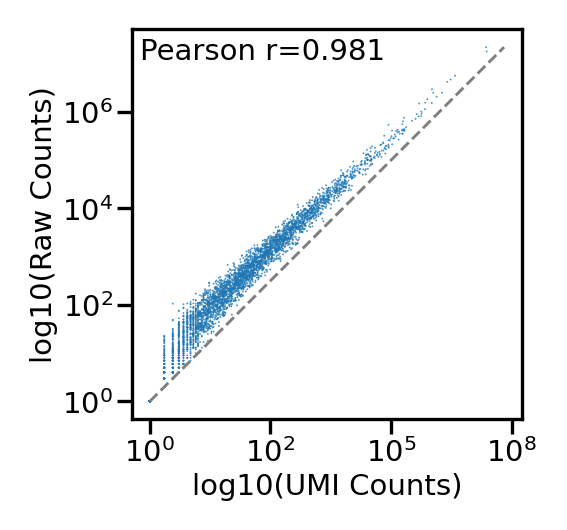

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.ticker as ticker

# 读取文件
data = pd.read_csv('umi_full/umi_full.csv')  # 替换为实际路径

# 转换为log10
data['log_probe_u'] = np.log10(data['probe_u'] + 1)  # log10 of UMI counts
data['log_probe_f'] = np.log10(data['probe_f'] + 1)  # log10 of raw counts

# 计算Pearson相关性
r, _ = pearsonr(data['log_probe_u'], data['log_probe_f'])

# 设置figure和坐标轴大小（3 cm × 3 cm -> inch）
cm2in = 1 / 2.54
ax_w_in = 3.3 * cm2in
ax_h_in = 3.3 * cm2in

left_in   = 0.25
bottom_in = 0.25
right_in  = 0.25
top_in    = 0.15

fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

# 创建figure
fig = plt.figure(figsize=(fig_w, fig_h), dpi=300, facecolor="none")

# 创建3cm x 3cm的轴
ax = fig.add_axes([
    left_in / fig_w,
    bottom_in / fig_h,
    ax_w_in / fig_w,
    ax_h_in / fig_h
])

# 绘制散点图
ax.scatter(data['log_probe_u'], data['log_probe_f'], s=0.2, alpha=0.8, edgecolors='none')


ax.text(
    0.02, 0.98,
    f"Pearson r={r:.3f}",
    transform=ax.transAxes,
    va='top', ha='left',
    fontsize=7,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0)
)

# 绘制y=x线（参考线）
mn = min(data['log_probe_u'].min(), data['log_probe_f'].min())
mx = max(data['log_probe_u'].max(), data['log_probe_f'].max())
ax.plot([mn, mx], [mn, mx], color='gray', lw=0.7, ls='--')

# 设置坐标轴标签
ax.set_xlabel("log10(UMI Counts)", fontsize=7,labelpad=1)
ax.set_ylabel("log10(Raw Counts)", fontsize=7,labelpad=1)


# 设置坐标轴比例一致
ax.set_aspect('equal', adjustable='box')

# 将坐标轴格式化为指数形式（10^x）
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'$10^{{{x:.0f}}}$'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'$10^{{{x:.0f}}}$'))

# 设置字体大小
ax.tick_params(axis='x', labelsize=7, pad=1)  # X轴刻度标签距离坐标轴的距离
ax.tick_params(axis='y', labelsize=7, pad=1)  # Y轴刻度标签距离坐标轴的距离


# 保存图像，透明背景
plt.tight_layout()
plt.savefig('umi_full/umi_full.png', dpi=300, bbox_inches="tight", pad_inches=0, transparent=True)
plt.savefig('umi_full/umi_full.pdf',
            bbox_inches="tight", pad_inches=0, transparent=True)
plt.show()


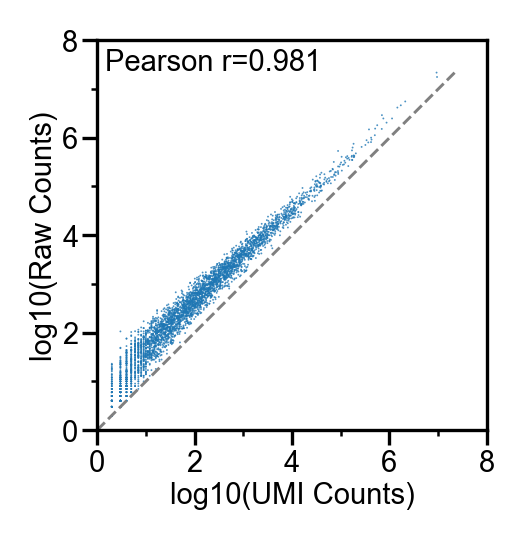

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.ticker as ticker

# ------- 关键：嵌入 TrueType 字体，避免 Type3 -------
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "text.usetex": False,          # 确保不走 TeX
})

# 读取文件
data = pd.read_csv('umi_full/umi_full.csv')

# 转换为log10
data['log_probe_u'] = np.log10(data['probe_u'] + 1)
data['log_probe_f'] = np.log10(data['probe_f'] + 1)

# Pearson
r, _ = pearsonr(data['log_probe_u'], data['log_probe_f'])

# ---- 固定轴尺寸：3.3cm × 3.3cm ----
cm2in = 1 / 2.54
ax_w_in = 3.3 * cm2in
ax_h_in = 3.3 * cm2in
left_in, bottom_in, right_in, top_in = 0.25, 0.25, 0.25, 0.15
fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

fig = plt.figure(figsize=(fig_w, fig_h), dpi=300, facecolor="none")
ax = fig.add_axes([
    left_in / fig_w,
    bottom_in / fig_h,
    ax_w_in / fig_w,
    ax_h_in / fig_h
])

# 散点
ax.scatter(data['log_probe_u'], data['log_probe_f'], s=0.2, alpha=0.8, edgecolors='none')

ax.text(
    0.02, 0.98,
    f"Pearson r={r:.3f}",
    transform=ax.transAxes,
    va='top', ha='left',
    fontsize=7,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0)
)

# y=x 参考线
mn = min(data['log_probe_u'].min(), data['log_probe_f'].min())
mx = max(data['log_probe_u'].max(), data['log_probe_f'].max())
ax.plot([mn, mx], [mn, mx], color='gray', lw=0.7, ls='--')

ax.set_xlabel("log10(UMI Counts)", fontsize=7, labelpad=1)
ax.set_ylabel("log10(Raw Counts)", fontsize=7, labelpad=1)
ax.set_aspect('equal', adjustable='box')
import matplotlib.ticker as ticker
import numpy as np

# --- Unicode 上标（避免 MathText，不用 $...$）---
_sup = str.maketrans("0123456789-+", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻⁺")
def fmt_10pow(x, _pos=None):
    k = int(np.round(x))
    return "10" + str(k).translate(_sup)

# （可选）先把轴范围设成整数 log10 边界，刻度更干净
xmin = np.floor(min(data['log_probe_u'].min(), data['log_probe_f'].min()))
xmax = np.ceil (max(data['log_probe_u'].max(), data['log_probe_f'].max()))
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)

# --- 主刻度：每 2（=每 10^2）---
# ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
# ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_10pow))
# ax.yaxis.set_major_formatter(ticker.FuncFormatter(fmt_10pow))

ax.set_xlim(0, 8)
ax.set_ylim(0, 8)

# （可选）次刻度：每 1（=每 10^1）不标数字，只做小刻度线
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.tick_params(which="minor", length=1.5)


ax.tick_params(axis='x', labelsize=7, pad=1)
ax.tick_params(axis='y', labelsize=7, pad=1)

# 保存：不要 tight_layout + tight bbox（避免尺寸被裁）
fig.savefig('umi_full/umi_full.pdf', dpi=300, bbox_inches=None, pad_inches=0, transparent=True)
fig.savefig('umi_full/umi_full.png', dpi=300, bbox_inches=None, pad_inches=0, transparent=True)
plt.show()
plt.close(fig)


<Figure size 640x480 with 0 Axes>

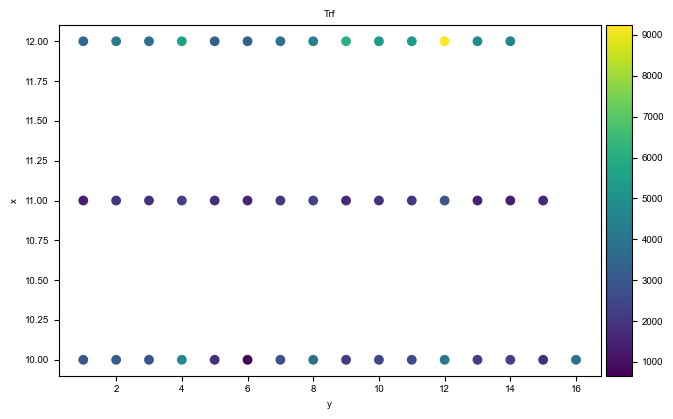

In [71]:
# 看基因的空间表达情况
import scanpy as sc
import numpy as np
import pandas as pd

adata = sc.read_h5ad("roi_norm_ubc1e6.h5ad")
mask = (adata.obs["x"] >9) & (adata.obs["x"] <13 )    
adata = adata[mask].copy()

#adata.obs.loc[(adata.obs["x"] < 4) & (adata.obs["y"] == 1), "sample"] = "spleem"
plt.figure()
sc.pl.scatter(adata, x="y", y="x", color="Trf", size=200)  # 注意 x/y 轴方向按你的习惯调整